In [1]:
import numpy as np
import matplotlib.pyplot as plt

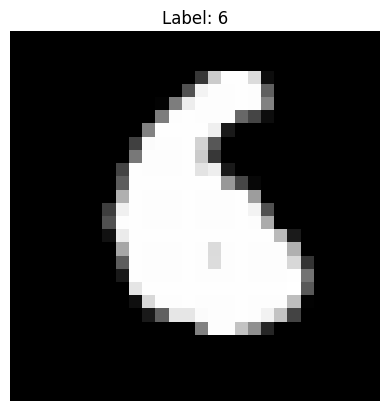

In [2]:
# Load the data from MNIST-5-6-Subset.txt
# Change the path as needed
data_file_path = "MNIST-5-6-Subset/MNIST-5-6-Subset.txt"
#data_file_path = "MNIST-5-6-Subset/MNIST-5-6-Subset-Light-Corruption.txt"
#data_file_path = "MNIST-5-6-Subset/MNIST-5-6-Subset-Moderate-Corruption.txt"
#data_file_path = "MNIST-5-6-Subset/MNIST-5-6-Subset-Heavy-Corruption.txt"
data_matrix = np.loadtxt(data_file_path).reshape(1877, 784)
# Load the labels from MNIST-5-6-Labels.txt
# Change the path as needed
labels_file_path = "MNIST-5-6-Subset/MNIST-5-6-Subset-Labels.txt"
labels = np.loadtxt(labels_file_path)

# Assuming you want to visualize the first image
# # Change the index as needed
# image_index = 50
# image_data = data_matrix[image_index]
# selected_label = int(labels[image_index])
# # Visualize the image using Matplotlib
# # We transpose the image to make the number look upright.
# plt.imshow(image_data.reshape(28,28).transpose(1,0), cmap='gray')
# plt.title(f"Label: {selected_label}")
# plt.axis('off') # Turn off axis
# plt.show()

# Loop through indices
for image_index in range(49, 50):
    image_data = data_matrix[image_index]
    selected_label = int(labels[image_index])
    
    # Visualize the image using Matplotlib
    # We transpose the image to make the number look upright.
    plt.imshow(image_data.reshape(28, 28).transpose(1, 0), cmap='gray')
    plt.title(f"Label: {selected_label}")
    plt.axis('off')  # Turn off axis
    
    plt.show()  # Show the image

First task, implementing the knn function that must return a vector of length m with average error for each value of K.

In [3]:
def knn(training_points, training_labels, test_points, test_labels):
    # convert labels from {5, 6} to {-1, 1}
    training_labels = np.where(training_labels == 5, -1, 1)
    test_labels = np.where(test_labels == 5, -1, 1)

    n = test_labels.size
    m = training_labels.size

    # transpose so we get the correct dimensions for the next part
    X_train = training_points.T # d x m
    X_targ = test_points.T # d x n

    # Calculating the distance matrix for training- and test points
    # (X_train)^T * X_train : matrix
    XtX = np.dot( X_train.T, X_train ) #

    # diag( (X_train)^T * X_train ) : returns a vector
    diag_XtX = np.diag(XtX)

    # (1^n)^T : vector
    # note: transposing a 1d array in python does nothing.
    one_n = np.ones(n)

    # (X_train)^T * X_targ : matrix
    XtY = np.dot(X_train.T, X_targ )

    # 1^m : vector
    one_m = np.ones(m)

    # (X_targ)^T * X_targ : matrix
    YtY = np.dot(X_targ.T, X_targ )

    # diag((X_targ)^T * X_targ) : vector
    diag_YtY = np.diag(YtY)

    # The final distance matrix m x n
    # note: we don't need to transpose the vector
    # to get the outer product, i.e. xz^T
    D = np.outer(diag_XtX, one_n) - 2*XtY + np.outer(one_m, diag_YtY)

    # Sort distances along columns
    sorted_indices = np.argsort(D, axis=0)

    # Map point indices to the their training label
    sorted_training_labels = training_labels[sorted_indices]

    # Find the errors, each row is the k'th neighbor,
    # compare estimated labels to the true labels
    found_errors = np.where(sorted_training_labels == test_labels, 0, 1, )

    # sum errors for each row
    sum_errors = np.sum(found_errors, axis=1)

    # count total errors found after k'th iteration 
    cumsum_errors = np.cumsum(sum_errors)
    
    # total neighbors searched after k'th iteration
    total_k_searched = np.cumsum ( np.full(m, n) )
    
    # return average error after k'th iteration
    return cumsum_errors / total_k_searched


Next task, for 4 values of n ∈{10, 20, 40, 80} plot knn using 5 validation sets i ∈{1,...,5}

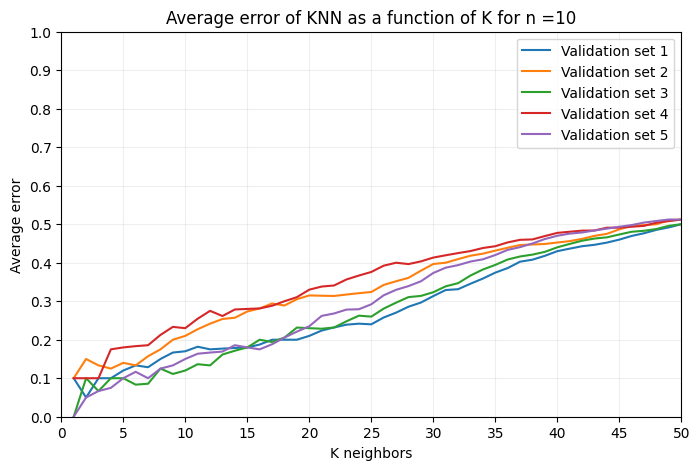

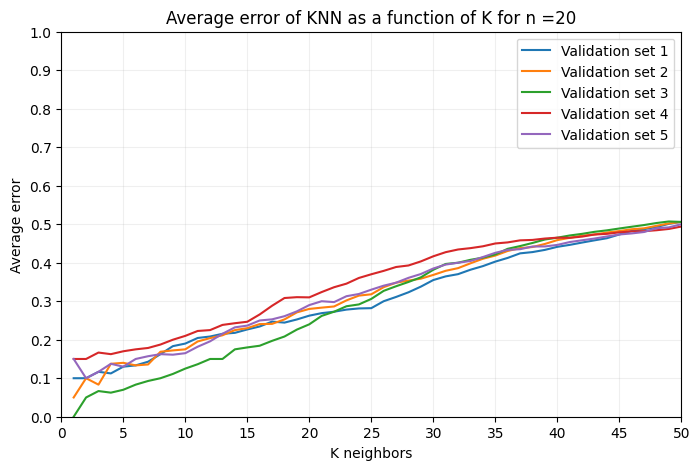

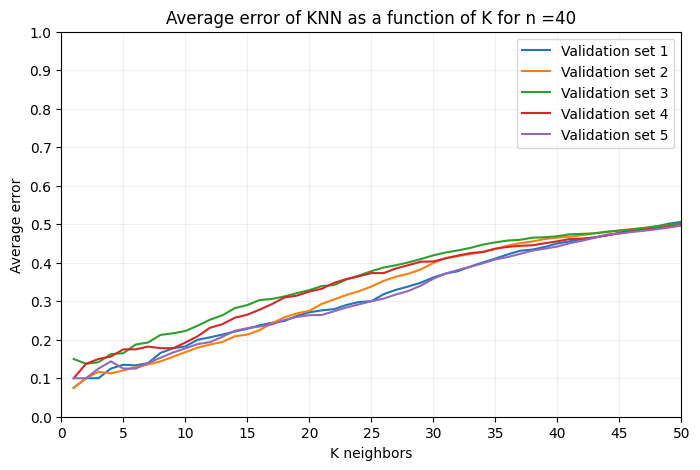

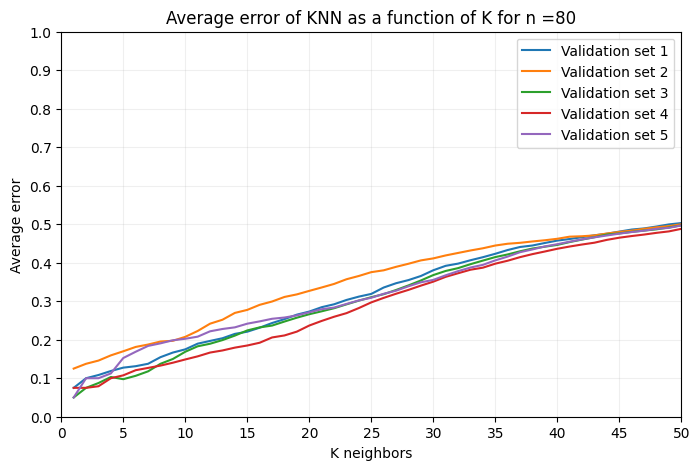

In [4]:
# get the specified validation set
def get_validation_set(i, m, n):
    row, col = m+(i-1)*n, m+i*n
    # points, labels
    return data_matrix[row:col, :], labels[row:col]

m = 50
n_interval = [10, 20, 40, 80]

# Extract the first m digits and labels (rows)
train_points = data_matrix[:m, :]
train_labels = labels[:m]

# plot the KNN graphs
for outer in range(0,4):
    n = n_interval[outer]
    x = np.arange(1, 51, 1)

    # Initialise figure (fig) and axis (ax)
    fig, ax = plt.subplots(figsize=(8,5))

    # Set labels and title
    ax.set_xlabel('K neighbors')
    ax.set_ylabel('Average error')
    ax.set_title(f'Average error of KNN as a function of K for n ={n}')

    # Add grid
    ax.grid(alpha=0.2)

    # Set axes limits
    ax.set_xlim(0,50)
    ax.set_ylim(0,1)

    # Set custom ticks for x and y axes
    ax.set_xticks(np.arange(0, 51, 5))  # Add more x-axis gridlines
    ax.set_yticks(np.arange(0, 1.1, 0.1))  # Add more y-axis gridlines

    for i in range(1,6):
        val_points, val_labels = get_validation_set(i, m, n)

        #
        y = knn(train_points,train_labels,val_points,val_labels) 
        
        # Plot in axis, add label to data
        ax.plot(x, y, label=f'Validation set {i}')
        # Add legend
        ax.legend()

    # Show plot
    plt.show()

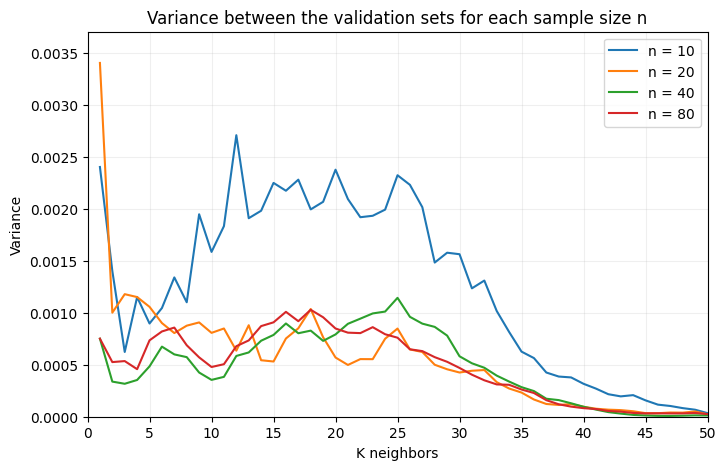

In [5]:
# Variance calculation plot
x = np.arange(1, 51, 1)

# Initialise figure (fig) and axis (ax)
fig, ax = plt.subplots(figsize=(8,5))

# Set labels and title
ax.set_xlabel('K neighbors')
ax.set_ylabel('Variance')
ax.set_title(f'Variance between the validation sets for each sample size n')

# Add grid
ax.grid(alpha=0.2)

# Set axes limits
ax.set_xlim(0,50)
ax.set_ylim(0, 0.0037)

# Set custom ticks for x and y axes
ax.set_xticks(np.arange(0, 51, 5))  # Add more x-axis gridlines

for n in n_interval:
    # setup empty matrix to hold error data
    variance = np.empty((0,0))

    for i in range(1, 6):
        val_points, val_labels = get_validation_set(i, m, n)

        errors = knn(train_points,train_labels,val_points,val_labels) 
        # if matrix is empty, set as error reshaped into a column vector
        if variance.size == 0:
            variance = errors.reshape(-1,1)
        # else append the error as a column
        else:
            variance = np.column_stack((variance, errors))

    y = np.var(variance, axis=1)

        
    # Plot in axis, add label to data
    ax.plot(x, y, label=f'n = {n}')
    # Add legend
    ax.legend()

# Show plot
plt.show()